In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [20]:
risk = pd.read_csv("../data/UCI_Credit_Card.csv")
risk.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [21]:
risk.shape

(30000, 25)

In [22]:
risk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [23]:
risk.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [24]:
risk["default.payment.next.month"].value_counts(normalize=True)

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [25]:
risk.groupby("default.payment.next.month")["LIMIT_BAL"].mean()

default.payment.next.month
0    178099.726074
1    130109.656420
Name: LIMIT_BAL, dtype: float64

In [26]:
risk.groupby("default.payment.next.month")["AGE"].mean()

default.payment.next.month
0    35.417266
1    35.725738
Name: AGE, dtype: float64

In [27]:
risk.groupby("default.payment.next.month")["PAY_0"].mean()

default.payment.next.month
0   -0.211222
1    0.668174
Name: PAY_0, dtype: float64

In [28]:
risk.groupby("default.payment.next.month")["PAY_2"].mean()

default.payment.next.month
0   -0.301917
1    0.458258
Name: PAY_2, dtype: float64

In [29]:
risk.groupby("default.payment.next.month")["PAY_0"].value_counts(normalize=True)

default.payment.next.month  PAY_0
0                            0       0.549949
                            -1       0.202534
                             1       0.104263
                            -2       0.102465
                             2       0.035225
                             3       0.003338
                             4       0.001027
                             5       0.000556
                             8       0.000342
                             6       0.000214
                             7       0.000086
1                            0       0.284509
                             2       0.277878
                             1       0.188668
                            -1       0.143761
                            -2       0.055003
                             3       0.036769
                             4       0.007836
                             5       0.001959
                             8       0.001658
                             7       0.001055


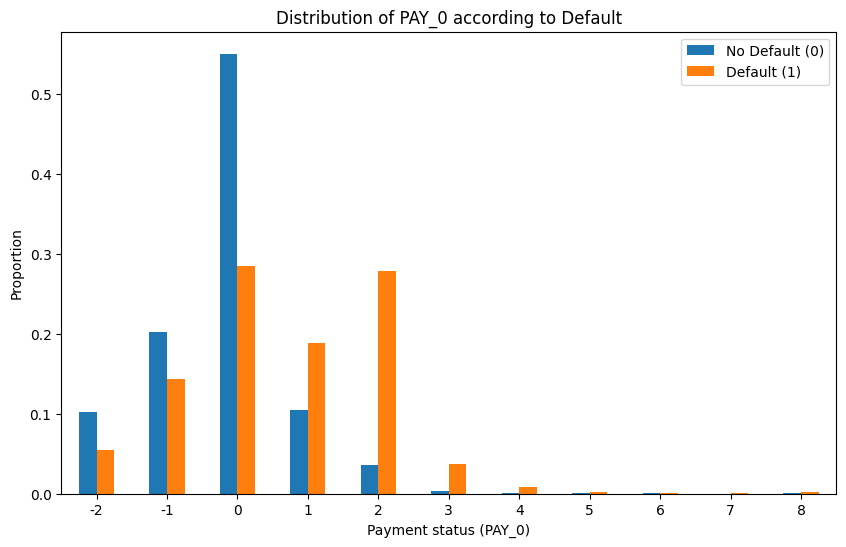

In [30]:
import matplotlib.pyplot as plt

# Calculate proportions
pay0_dist = (
    risk.groupby("default.payment.next.month")["PAY_0"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

# pivot to make graphing easier
pay0_pivot = pay0_dist.pivot(
    index="PAY_0",
    columns="default.payment.next.month",
    values="proportion"
)

# sort values ​​of PAY_0
pay0_pivot = pay0_pivot.sort_index()

# Plotting (capture axis)
ax = pay0_pivot.plot(kind="bar", figsize=(10,6))

plt.title("Distribution of PAY_0 according to Default")
plt.ylabel("Proportion")
plt.xlabel("Payment status (PAY_0)")
plt.legend(["No Default (0)", "Default (1)"])
plt.xticks(rotation=0)

# Get figure object
fig = ax.get_figure()

# Save BEFORE show
fig.savefig(
    "../reports/figures/pay0_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

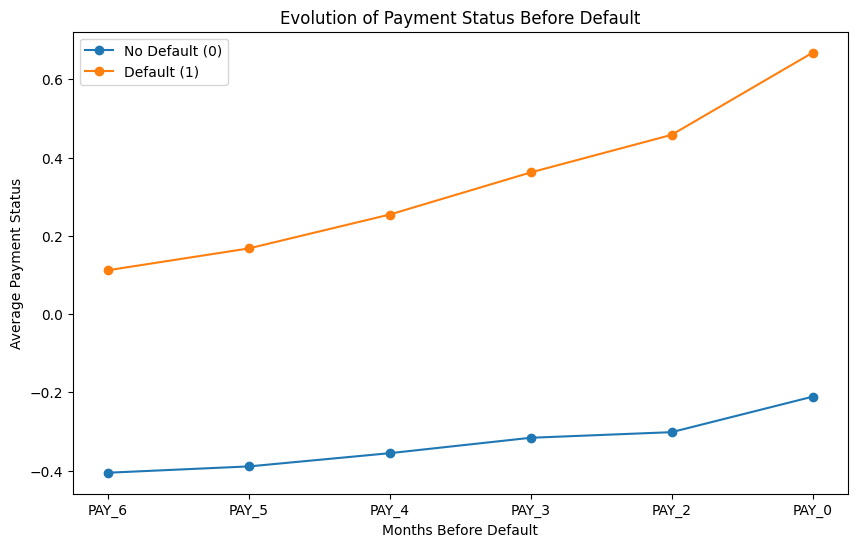

In [31]:

# We checked that the folder exists
os.makedirs("../reports/figures", exist_ok=True)

# List in chronological order (from oldest to newest)
pay_cols = ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_0"]

# Calculate averages per group
mean_pay = risk.groupby("default.payment.next.month")[pay_cols].mean().T

# Plotting
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(mean_pay.index, mean_pay[0], marker="o", label="No Default (0)")
ax.plot(mean_pay.index, mean_pay[1], marker="o", label="Default (1)")

ax.set_title("Evolution of Payment Status Before Default")
ax.set_ylabel("Average Payment Status")
ax.set_xlabel("Months Before Default")
ax.legend()

fig.savefig(
    "../reports/figures/pay_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

risk.groupby("default.payment.next.month")[bill_cols].mean()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
default.payment.next.month,,,,,,
0,51994.227273,49717.435670,47533.365605,43611.165254,40530.445343,39042.268704
1,48509.162297,47283.617842,45181.598855,42036.950573,39540.190476,38271.435503


In [33]:
risk.groupby("default.payment.next.month")[pay_cols].mean()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
default.payment.next.month,,,,,,
0,6307.337357,6640.465074,5753.496833,5300.529319,5248.220296,5719.371769
1,3397.044153,3388.649638,3367.351567,3155.626733,3219.139542,3441.482068


In [34]:
import numpy as np

for i in range(1, 7):
    risk[f"PAY_RATIO_{i}"] = np.where(
        risk[f"BILL_AMT{i}"] > 0,
        risk[f"PAY_AMT{i}"] / risk[f"BILL_AMT{i}"],
        0
    )

In [35]:
ratio_cols = [f"PAY_RATIO_{i}" for i in range(1, 7)]
risk.groupby("default.payment.next.month")[ratio_cols].mean()

,PAY_RATIO_1,PAY_RATIO_2,PAY_RATIO_3,PAY_RATIO_4,PAY_RATIO_5,PAY_RATIO_6
default.payment.next.month,,,,,,
0,1.857202,1.732605,1.604845,1.892326,1.164139,1.394357
1,0.795108,0.627417,1.634090,0.631042,0.746627,0.945950


In [36]:
# Because we need to reduce the impact of outliers, we will use the median.

risk.groupby("default.payment.next.month")[ratio_cols].median()

,PAY_RATIO_1,PAY_RATIO_2,PAY_RATIO_3,PAY_RATIO_4,PAY_RATIO_5,PAY_RATIO_6
default.payment.next.month,,,,,,
0,0.05562,0.053204,0.043697,0.038724,0.041139,0.040533
1,0.04585,0.044048,0.036851,0.036460,0.037275,0.037057


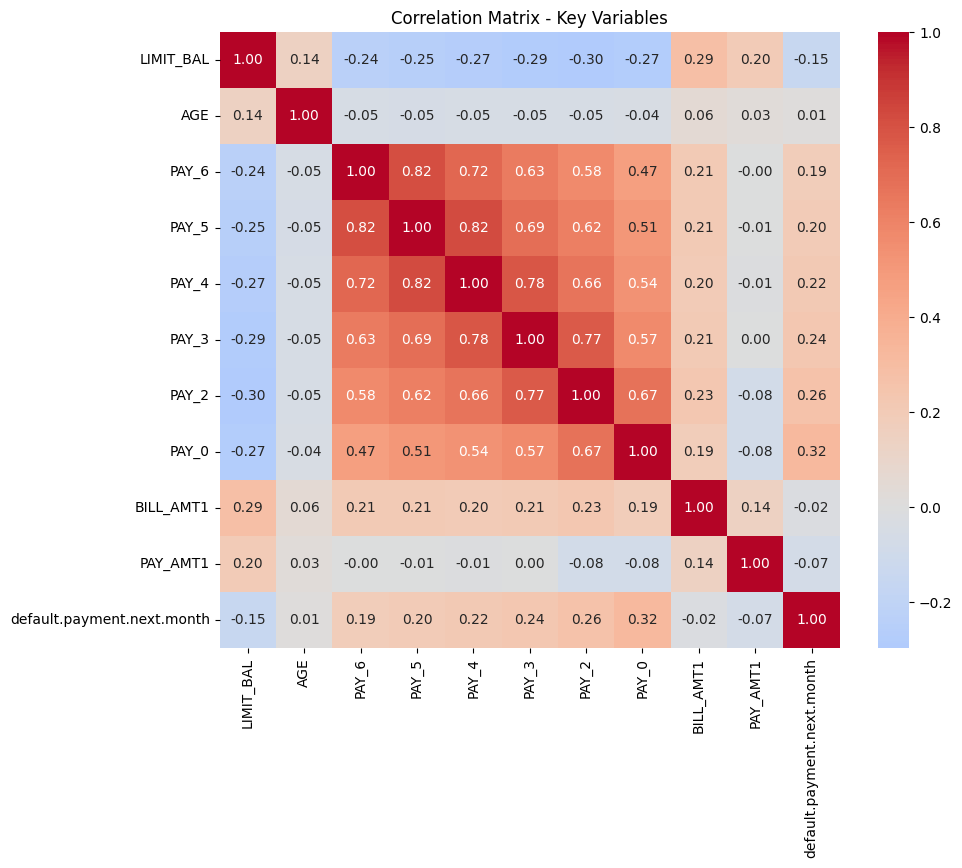

In [38]:
os.makedirs("../reports/figures", exist_ok=True)

cols_for_corr = [
    "LIMIT_BAL", "AGE",
    "PAY_6","PAY_5","PAY_4","PAY_3","PAY_2","PAY_0",
    "BILL_AMT1","PAY_AMT1",
    "default.payment.next.month"
]

corr_matrix = risk[cols_for_corr].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Key Variables")

plt.savefig(
    "../reports/figures/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()